# Impacts of Over Sampling

### Classification with TimeGAN

In [1]:
import os
import pickle
import numpy as np

# ══════════════════════════════════════════════════════════════
# LOAD SAVED TIMEGAN DATASETS
# Input folder : ./timegan_datasets
# Output      : timegan_datasets
# ══════════════════════════════════════════════════════════════

DATASET_SAVE_DIR = "./timegan_datasets"

TARGET_VARIANTS = [
    "timegan_balanced",
    "timegan_8000",
    "timegan_4000",
    "timegan_2000",
    "timegan_1000",
    "timegan_500",
]

timegan_datasets = {}

for dataset_name in TARGET_VARIANTS:

    file_path = os.path.join(DATASET_SAVE_DIR, f"{dataset_name}.pkl")

    if not os.path.exists(file_path):
        print(f"⚠️ Missing file: {file_path}")
        continue

    with open(file_path, "rb") as f:
        d = pickle.load(f)

    # Make sure arrays are float32
    d["X_train"] = d["X_train"].astype(np.float32)
    d["X_val"]   = d["X_val"].astype(np.float32)
    d["X_test"]  = d["X_test"].astype(np.float32)

    timegan_datasets[dataset_name] = d

    train_counts = np.bincount(d["y_train"].astype(int), minlength=2)
    val_counts   = np.bincount(d["y_val"].astype(int), minlength=2)
    test_counts  = np.bincount(d["y_test"].astype(int), minlength=2)

    print(f"\nLoaded: {dataset_name}")
    print(f"  Train: {d['X_train'].shape} | Non-SEP={train_counts[0]} | SEP={train_counts[1]}")
    print(f"  Val  : {d['X_val'].shape} | Non-SEP={val_counts[0]} | SEP={val_counts[1]}")
    print(f"  Test : {d['X_test'].shape} | Non-SEP={test_counts[0]} | SEP={test_counts[1]}")
    print(f"  Real SEP      : {d.get('real_sep', None)}")
    print(f"  Synthetic SEP : {d.get('synthetic_sep', None)}")
    print(f"  Use RUS       : {d.get('use_rus', None)}")

print("\n✅ Loaded TimeGAN datasets:")
print(list(timegan_datasets.keys()))


Loaded: timegan_balanced
  Train: (24300, 288, 10) | Non-SEP=12150 | SEP=12150
  Val  : (1780, 288, 10) | Non-SEP=1763 | SEP=17
  Test : (3559, 288, 10) | Non-SEP=3525 | SEP=34
  Real SEP      : 118
  Synthetic SEP : 12032
  Use RUS       : False

Loaded: timegan_8000
  Train: (16000, 288, 10) | Non-SEP=8000 | SEP=8000
  Val  : (1780, 288, 10) | Non-SEP=1763 | SEP=17
  Test : (3559, 288, 10) | Non-SEP=3525 | SEP=34
  Real SEP      : 118
  Synthetic SEP : 7882
  Use RUS       : True

Loaded: timegan_4000
  Train: (8000, 288, 10) | Non-SEP=4000 | SEP=4000
  Val  : (1780, 288, 10) | Non-SEP=1763 | SEP=17
  Test : (3559, 288, 10) | Non-SEP=3525 | SEP=34
  Real SEP      : 118
  Synthetic SEP : 3882
  Use RUS       : True

Loaded: timegan_2000
  Train: (4000, 288, 10) | Non-SEP=2000 | SEP=2000
  Val  : (1780, 288, 10) | Non-SEP=1763 | SEP=17
  Test : (3559, 288, 10) | Non-SEP=3525 | SEP=34
  Real SEP      : 118
  Synthetic SEP : 1882
  Use RUS       : True

Loaded: timegan_1000
  Train: (20

### Catch22 Vectorization for SVM

In [2]:
import numpy as np
from joblib import Parallel, delayed
from sktime.transformations.panel.catch22 import Catch22
from sklearn.impute import SimpleImputer
import warnings

# ══════════════════════════════════════════════════════════════
# CATCH22 FEATURE EXTRACTION FOR ENN + TIMEGAN DATASETS
# Input : timegan_datasets
#         timegan_balanced,
#         timegan_8000,
#         timegan_4000,
#         timegan_2000,
#         timegan_1000,
#         timegan_500
# Output: datasets_svm_timegan
# ══════════════════════════════════════════════════════════════

TARGET_VARIANTS = [
    "timegan_balanced",
    "timegan_8000",
    "timegan_4000",
    "timegan_2000",
    "timegan_1000",
    "timegan_500",
]


def _catch22_chunk(X_chunk):
    transformer = Catch22(catch24=False)
    return transformer.fit_transform(X_chunk).to_numpy()


def extract_catch22(X, label="", n_jobs=-1, chunk_size=200):

    n_samples, n_timepoints, n_channels = X.shape

    # Replace NaN / Inf before Catch22
    if not np.isfinite(X).all():
        n_bad = (~np.isfinite(X)).sum()
        print(f"    ⚠️ {n_bad} non-finite values in {label} — replacing with channel median")

        X = X.copy()

        for c in range(n_channels):
            col = X[:, :, c]
            median_c = np.nanmedian(col)

            if not np.isfinite(median_c):
                median_c = 0.0

            col[~np.isfinite(col)] = median_c
            X[:, :, c] = col

    # sktime expects shape: (samples, channels, timesteps)
    X_sktime = X.transpose(0, 2, 1).astype(np.float64)

    chunks = [
        X_sktime[i:i + chunk_size]
        for i in range(0, n_samples, chunk_size)
    ]

    print(f"    {label}: {n_samples} samples in {len(chunks)} chunks", flush=True)

    results = Parallel(n_jobs=n_jobs)(
        delayed(_catch22_chunk)(chunk)
        for chunk in chunks
    )

    X_feat = np.vstack(results)

    expected_cols = 22 * n_channels

    assert X_feat.shape == (n_samples, expected_cols), (
        f"Unexpected shape for {label}: {X_feat.shape}, "
        f"expected ({n_samples}, {expected_cols})"
    )

    return X_feat.astype(np.float32)


# ══════════════════════════════════════════════════════════════
# Sanity check before extraction
# ══════════════════════════════════════════════════════════════

print("Pre-extraction value range check:")
print(
    f"{'Dataset':<18} "
    f"{'Train shape':<22} "
    f"{'Finite?':<10} "
    f"{'Min':>12} "
    f"{'Max':>12} "
    f"{'NaN/Inf':>10} "
    f"{'Class 0':>8} "
    f"{'Class 1':>8} "
    f"{'Ratio':>8}"
)
print("─" * 120)

for dataset_name in TARGET_VARIANTS:

    if dataset_name not in timegan_datasets:
        print(f"[{dataset_name}] not found — skipping")
        continue

    d = timegan_datasets[dataset_name]
    X = d["X_train"]
    y = d["y_train"]

    counts = np.bincount(y.astype(int), minlength=2)
    ratio = counts[0] / counts[1] if counts[1] > 0 else np.inf

    print(
        f"{dataset_name:<18} "
        f"{str(X.shape):<22} "
        f"{str(np.isfinite(X).all()):<10} "
        f"{np.nanmin(X):>12.4f} "
        f"{np.nanmax(X):>12.4f} "
        f"{(~np.isfinite(X)).sum():>10} "
        f"{counts[0]:>8} "
        f"{counts[1]:>8} "
        f"{ratio:>7.1f}x"
    )


# ══════════════════════════════════════════════════════════════
# Extract Catch22 features
# ══════════════════════════════════════════════════════════════

datasets_svm_timegan = {}

print("\nExtracting Catch22 features for ENN + TimeGAN datasets...")

for dataset_name in TARGET_VARIANTS:

    if dataset_name not in timegan_datasets:
        print(f"[{dataset_name}] not found — skipping")
        continue

    d = timegan_datasets[dataset_name]

    print(f"\n[{dataset_name}] extracting train...")
    X_tr = extract_catch22(
        d["X_train"],
        label=f"{dataset_name}/train",
        n_jobs=-1,
        chunk_size=200
    )

    print(f"[{dataset_name}] extracting val...")
    X_va = extract_catch22(
        d["X_val"],
        label=f"{dataset_name}/val",
        n_jobs=-1,
        chunk_size=200
    )

    print(f"[{dataset_name}] extracting test...")
    X_te = extract_catch22(
        d["X_test"],
        label=f"{dataset_name}/test",
        n_jobs=-1,
        chunk_size=200
    )

    datasets_svm_timegan[dataset_name] = {
        "X_train": X_tr,
        "y_train": d["y_train"],

        "X_val": X_va,
        "y_val": d["y_val"],

        "X_test": X_te,
        "y_test": d["y_test"],

        "real_sep": d.get("real_sep", None),
        "synthetic_sep": d.get("synthetic_sep", None),
        "nsep": d.get("nsep", None),
        "sep": d.get("sep", None),
        "use_rus": d.get("use_rus", None),
    }

    print(
        f"[{dataset_name}] ✓ "
        f"train {X_tr.shape} | "
        f"val {X_va.shape} | "
        f"test {X_te.shape}"
    )


# ══════════════════════════════════════════════════════════════
# Impute Catch22 features
# Fit imputer on train only, apply to val/test
# ══════════════════════════════════════════════════════════════

print("\nChecking and imputing Catch22 features...")

for dataset_name in list(datasets_svm_timegan.keys()):

    d = datasets_svm_timegan[dataset_name]

    X_tr = d["X_train"].copy()
    X_va = d["X_val"].copy()
    X_te = d["X_test"].copy()

    y_tr = d["y_train"]
    y_va = d["y_val"]
    y_te = d["y_test"]

    n_bad_tr = (~np.isfinite(X_tr)).sum()
    n_bad_va = (~np.isfinite(X_va)).sum()
    n_bad_te = (~np.isfinite(X_te)).sum()

    if n_bad_tr > 0 or n_bad_va > 0 or n_bad_te > 0:

        print(
            f"  ⚠️ [{dataset_name}] non-finite values — "
            f"train: {n_bad_tr}, val: {n_bad_va}, test: {n_bad_te} → imputing"
        )

        X_tr = np.where(np.isfinite(X_tr), X_tr, np.nan)
        X_va = np.where(np.isfinite(X_va), X_va, np.nan)
        X_te = np.where(np.isfinite(X_te), X_te, np.nan)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            imputer = SimpleImputer(strategy="median")

            X_tr = imputer.fit_transform(X_tr)
            X_va = imputer.transform(X_va)
            X_te = imputer.transform(X_te)

        X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
        X_va = np.nan_to_num(X_va, nan=0.0, posinf=0.0, neginf=0.0)
        X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)

        print(f"  ✓ [{dataset_name}] imputed")

    else:
        print(f"  ✓ [{dataset_name}] no NaN or Inf")

    datasets_svm_timegan[dataset_name] = {
        "X_train": X_tr.astype(np.float32),
        "y_train": y_tr,

        "X_val": X_va.astype(np.float32),
        "y_val": y_va,

        "X_test": X_te.astype(np.float32),
        "y_test": y_te,

        "real_sep": d.get("real_sep", None),
        "synthetic_sep": d.get("synthetic_sep", None),
        "nsep": d.get("nsep", None),
        "sep": d.get("sep", None),
        "use_rus": d.get("use_rus", None),
    }


# ══════════════════════════════════════════════════════════════
# Final summary
# ══════════════════════════════════════════════════════════════

print("\n✅ SVM-ready Catch22 ENN + TimeGAN datasets are ready:")
print(list(datasets_svm_timegan.keys()))

print(
    f"\n{'Dataset':<18} "
    f"{'Train shape':<18} "
    f"{'Val shape':<18} "
    f"{'Test shape':<18} "
    f"{'Class 0':>8} "
    f"{'Class 1':>8} "
    f"{'Ratio':>8}"
)
print("─" * 105)

for name, d in datasets_svm_timegan.items():
    counts = np.bincount(d["y_train"].astype(int), minlength=2)
    ratio = counts[0] / counts[1] if counts[1] > 0 else np.inf

    print(
        f"{name:<18} "
        f"{str(d['X_train'].shape):<18} "
        f"{str(d['X_val'].shape):<18} "
        f"{str(d['X_test'].shape):<18} "
        f"{counts[0]:>8} "
        f"{counts[1]:>8} "
        f"{ratio:>7.1f}x"
    )

Pre-extraction value range check:
Dataset            Train shape            Finite?             Min          Max    NaN/Inf  Class 0  Class 1    Ratio
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
timegan_balanced   (24300, 288, 10)       True            -6.5136      27.8326          0    12150    12150     1.0x
timegan_8000       (16000, 288, 10)       True            -6.5136      27.2851          0     8000     8000     1.0x
timegan_4000       (8000, 288, 10)        True            -6.5136      27.2851          0     4000     4000     1.0x
timegan_2000       (4000, 288, 10)        True            -6.5136      27.2851          0     2000     2000     1.0x
timegan_1000       (2000, 288, 10)        True            -6.5136      27.8326          0     1000     1000     1.0x
timegan_500        (1000, 288, 10)        True            -6.5136      27.2851          0      500      500     1.0x

Extracting Catch22 featur

### Classification

In [7]:
# ══════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
import time
import os

RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def compute_metrics(y_true, y_pred):
    cm             = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy  = (TP + TN) / (TP + TN + FP + FN)

    tss  = recall - FP / (FP + TN) if (FP + TN) > 0 else 0.0

    expected = ((TP + FN) * (TP + FP) + (TN + FP) * (TN + FN)) / (TP + TN + FP + FN) ** 2
    hss1     = (accuracy - expected) / (1 - expected) if (1 - expected) > 0 else 0.0

    denom = ((TP + FN) * (FN + TN) + (TP + FP) * (FP + TN))
    hss2  = 2 * (TP * TN - FP * FN) / denom if denom > 0 else 0.0

    hits_random = (TP + FP) * (TP + FN) / (TP + TN + FP + FN)
    gss = (TP - hits_random) / (TP + FP + FN - hits_random) if (TP + FP + FN - hits_random) > 0 else 0.0

    return {
        'TP': int(TP), 'TN': int(TN), 'FP': int(FP), 'FN': int(FN),
        'tss': tss, 'hss1': hss1, 'hss2': hss2, 'gss': gss,
        'recall': recall, 'f1': f1, 'accuracy': accuracy
    }


def train_and_evaluate(model, X_train, y_train, X_test, y_test):
    t0         = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t0         = time.time()
    y_pred     = model.predict(X_test)
    infer_time = time.time() - t0

    metrics = compute_metrics(y_test, y_pred)
    metrics['train_time'] = train_time
    metrics['infer_time'] = infer_time
    return metrics


def save_results(metrics_list, filepath):
    with open(filepath, 'w') as f:
        for m in metrics_list:
            line = (f"{m['TP']},{m['TN']},{m['FP']},{m['FN']},"
                    f"{m['tss']:.6f},{m['hss1']:.6f},{m['hss2']:.6f},{m['gss']:.6f},"
                    f"{m['recall']:.6f},{m['f1']:.6f},{m['accuracy']:.6f},"
                    f"{m['train_time']:.4f},{m['infer_time']:.4f}")
            f.write(line + "\n")


def print_results(metrics_list, title):
    keys = ['tss', 'hss1', 'hss2', 'gss', 'recall', 'f1', 'accuracy', 'train_time', 'infer_time']
    print(f"\n{'─'*55}")
    print(f"  {title}")
    print(f"{'─'*55}")
    for i, m in enumerate(metrics_list):
        print(f"  Run {i+1}: TP={m['TP']}  TN={m['TN']}  FP={m['FP']}  FN={m['FN']}")
        print(f"         TSS={m['tss']:.4f}  HSS1={m['hss1']:.4f}  HSS2={m['hss2']:.4f}  GSS={m['gss']:.4f}")
        print(f"         Recall={m['recall']:.4f}  F1={m['f1']:.4f}  Acc={m['accuracy']:.4f}")
        print(f"         Train={m['train_time']:.2f}s  Infer={m['infer_time']:.4f}s")
        print()
    print(f"  ── Average of {len(metrics_list)} runs ──")
    for k in keys:
        avg = np.mean([m[k] for m in metrics_list])
        print(f"  {k:<12} : {avg:.4f}")
    print(f"{'─'*55}")

### SVM

In [8]:
# ══════════════════════════════════════════════════════════════
# SVM EXPERIMENTS — ENN + TIMEGAN
# Step 1: Search best SVM hyperparameters on validation set
# Step 2: Run final experiments on all TimeGAN variants using best params
#
# Input datasets:
# datasets_svm_timegan
#   timegan_balanced
#   timegan_8000
#   timegan_4000
#   timegan_2000
#   timegan_1000
#   timegan_500
# ══════════════════════════════════════════════════════════════

import os
import time
import copy
import warnings
import numpy as np

from sklearn.svm import SVC, LinearSVC
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------
# Target TimeGAN variants
# ---------------------------------------------------------

TARGET_VARIANTS = [
    "timegan_balanced",
    "timegan_8000",
    "timegan_4000",
    "timegan_2000",
    "timegan_1000",
    "timegan_500",
]

# Use one reference variant for hyperparameter selection.
# This keeps the comparison fair because all variants use the same final SVM.
TUNE_VARIANT = "timegan_8000"

# ══════════════════════════════════════════════════════════════
# SVM HYPERPARAMETER GRID
# Tune on TimeGAN validation set
# ══════════════════════════════════════════════════════════════

SVM_GRID = [
    {"model": LinearSVC, "params": {"C": 0.01, "class_weight": "balanced", "max_iter": 10000}},
    {"model": LinearSVC, "params": {"C": 0.05, "class_weight": "balanced", "max_iter": 10000}},
    {"model": LinearSVC, "params": {"C": 0.1,  "class_weight": "balanced", "max_iter": 10000}},
    {"model": LinearSVC, "params": {"C": 0.5,  "class_weight": "balanced", "max_iter": 10000}},
    {"model": LinearSVC, "params": {"C": 1.0,  "class_weight": "balanced", "max_iter": 10000}},
    {"model": LinearSVC, "params": {"C": 3.0,  "class_weight": "balanced", "max_iter": 10000}},

    {"model": SVC, "params": {"kernel": "rbf", "C": 0.01, "gamma": "scale", "class_weight": "balanced", "cache_size": 2000}},
    {"model": SVC, "params": {"kernel": "rbf", "C": 0.1,  "gamma": "scale", "class_weight": "balanced", "cache_size": 2000}},
    {"model": SVC, "params": {"kernel": "rbf", "C": 1.0,  "gamma": "scale", "class_weight": "balanced", "cache_size": 2000}},
    {"model": SVC, "params": {"kernel": "rbf", "C": 10.0, "gamma": "scale", "class_weight": "balanced", "cache_size": 2000}},
]


def combo_label(combo):
    ModelClass = combo["model"]
    params = combo["params"]

    cw = "balanced" if params.get("class_weight") == "balanced" else "none"

    if ModelClass == LinearSVC:
        return f"LinearSVC | C={params['C']} | cw={cw}"
    else:
        return f"RBF-SVC   | C={params['C']} | gamma={params['gamma']} | cw={cw}"


# ══════════════════════════════════════════════════════════════
# STEP 1 — SEARCH BEST HYPERPARAMETERS ON VALIDATION SET
# ══════════════════════════════════════════════════════════════

if TUNE_VARIANT not in datasets_svm_timegan:
    raise ValueError(f"TUNE_VARIANT '{TUNE_VARIANT}' not found in datasets_svm_timegan.")

d_tune = datasets_svm_timegan[TUNE_VARIANT]

print("═" * 70)
print("SVM hyperparameter search on ENN + TimeGAN validation set")
print("═" * 70)
print(f"Tuning variant: {TUNE_VARIANT}")
print(f"Train shape   : {d_tune['X_train'].shape}")
print(f"Val shape     : {d_tune['X_val'].shape}")
print("═" * 70)

train_counts = np.bincount(d_tune["y_train"].astype(int), minlength=2)
val_counts = np.bincount(d_tune["y_val"].astype(int), minlength=2)

train_ratio = train_counts[0] / train_counts[1] if train_counts[1] > 0 else np.inf

print(f"Train class: NSEP={train_counts[0]} | SEP={train_counts[1]} | Ratio={train_ratio:.1f}:1")
print(f"Val class  : NSEP={val_counts[0]} | SEP={val_counts[1]}")
print("─" * 70)

best_tss = -np.inf
best_model_class = None
best_params = None
best_val_metrics = None

for i, combo in enumerate(SVM_GRID):

    ModelClass = combo["model"]
    params = copy.deepcopy(combo["params"])

    print(f"[{i + 1}/{len(SVM_GRID)}] {combo_label(combo)}", flush=True)

    model = ModelClass(**params)

    t0 = time.time()
    model.fit(d_tune["X_train"], d_tune["y_train"])
    y_val_pred = model.predict(d_tune["X_val"])
    elapsed = time.time() - t0

    val_metrics = compute_metrics(d_tune["y_val"], y_val_pred)

    precision_text = (
        f" | Precision={val_metrics['precision']:.4f}"
        if "precision" in val_metrics else ""
    )

    print(
        f"    Val TSS={val_metrics['tss']:.4f} | "
        f"F1={val_metrics['f1']:.4f} | "
        f"Recall={val_metrics['recall']:.4f}"
        f"{precision_text} | "
        f"Time={elapsed:.1f}s\n"
    )

    if val_metrics["tss"] > best_tss:
        best_tss = val_metrics["tss"]
        best_model_class = ModelClass
        best_params = params
        best_val_metrics = val_metrics


print("Best SVM hyperparameters selected from TimeGAN validation set:")
print(f"  Tuning variant : {TUNE_VARIANT}")
print(f"  Model          : {best_model_class.__name__}")
print(f"  Params         : {best_params}")
print(f"  Val TSS        : {best_tss:.4f}")
print(f"  Val F1         : {best_val_metrics['f1']:.4f}")
print(f"  Val Recall     : {best_val_metrics['recall']:.4f}")
if "precision" in best_val_metrics:
    print(f"  Val Precision  : {best_val_metrics['precision']:.4f}")


# ══════════════════════════════════════════════════════════════
# STEP 2 — RUN FINAL EXPERIMENTS ON ALL ENN + TIMEGAN DATASETS
# ══════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("Final SVM experiments on ENN + TimeGAN datasets")
print("Using best hyperparameters selected from validation")
print("═" * 70)
print(f"Model  : {best_model_class.__name__}")
print(f"Params : {best_params}")

all_timegan_svm_results = {}

for dataset_key in TARGET_VARIANTS:

    if dataset_key not in datasets_svm_timegan:
        print(f"[{dataset_key}] not found — skipping")
        continue

    d = datasets_svm_timegan[dataset_key]

    print("\n" + "─" * 70)
    print(f"Dataset : {dataset_key}")
    print(f"Model   : {best_model_class.__name__}")
    print(f"Params  : {best_params}")

    train_counts = np.bincount(d["y_train"].astype(int), minlength=2)
    val_counts   = np.bincount(d["y_val"].astype(int), minlength=2)
    test_counts  = np.bincount(d["y_test"].astype(int), minlength=2)

    train_ratio = train_counts[0] / train_counts[1] if train_counts[1] > 0 else np.inf

    print(f"Train shape   : {d['X_train'].shape}")
    print(f"Val shape     : {d['X_val'].shape}")
    print(f"Test shape    : {d['X_test'].shape}")
    print(f"Train class   : NSEP={train_counts[0]} | SEP={train_counts[1]} | Ratio={train_ratio:.1f}:1")
    print(f"Val class     : NSEP={val_counts[0]} | SEP={val_counts[1]}")
    print(f"Test class    : NSEP={test_counts[0]} | SEP={test_counts[1]}")
    print(f"Real SEP      : {d.get('real_sep', None)}")
    print(f"Synthetic SEP : {d.get('synthetic_sep', None)}")
    print(f"Use RUS       : {d.get('use_rus', None)}")
    print("─" * 70)

    metrics_list = []

    for run in range(2):

        model = best_model_class(**copy.deepcopy(best_params))

        metrics = train_and_evaluate(
            model,
            d["X_train"], d["y_train"],
            d["X_test"],  d["y_test"]
        )

        metrics_list.append(metrics)

        precision_text = (
            f" | Precision={metrics['precision']:.4f}"
            if "precision" in metrics else ""
        )

        print(
            f"Run {run + 1}: "
            f"TSS={metrics['tss']:.4f} | "
            f"F1={metrics['f1']:.4f} | "
            f"Recall={metrics['recall']:.4f}"
            f"{precision_text} | "
            f"Train={metrics['train_time']:.2f}s"
        )

    all_timegan_svm_results[dataset_key] = metrics_list

    filepath = os.path.join(RESULTS_DIR, f"svm_{dataset_key}.txt")
    save_results(metrics_list, filepath)
    print_results(metrics_list, f"SVM | {dataset_key}")


# ══════════════════════════════════════════════════════════════
# STEP 3 — SELECT BEST TIMEGAN DATASET BY AVERAGE TEST TSS
# ══════════════════════════════════════════════════════════════

best_dataset = None
best_avg_tss = -np.inf

print("\n" + "═" * 70)
print("SVM ENN + TimeGAN summary")
print("═" * 70)

print(
    f"{'Dataset':<18} "
    f"{'NSEP':>8} "
    f"{'SEP':>8} "
    f"{'Ratio':>10} "
    f"{'Real SEP':>10} "
    f"{'Syn SEP':>10} "
    f"{'RUS?':>8} "
    f"{'Avg TSS':>10} "
    f"{'Avg F1':>10} "
    f"{'Avg Recall':>12}"
)
print("─" * 120)

for dataset_key, metrics_list in all_timegan_svm_results.items():

    d = datasets_svm_timegan[dataset_key]

    counts = np.bincount(d["y_train"].astype(int), minlength=2)
    ratio = counts[0] / counts[1] if counts[1] > 0 else np.inf

    avg_tss = np.mean([m["tss"] for m in metrics_list])
    avg_f1 = np.mean([m["f1"] for m in metrics_list])
    avg_recall = np.mean([m["recall"] for m in metrics_list])

    real_sep = d.get("real_sep", None)
    synthetic_sep = d.get("synthetic_sep", None)
    use_rus = d.get("use_rus", None)

    print(
        f"{dataset_key:<18} "
        f"{counts[0]:>8} "
        f"{counts[1]:>8} "
        f"{ratio:>9.1f}x "
        f"{str(real_sep):>10} "
        f"{str(synthetic_sep):>10} "
        f"{str(use_rus):>8} "
        f"{avg_tss:>10.4f} "
        f"{avg_f1:>10.4f} "
        f"{avg_recall:>12.4f}"
    )

    if avg_tss > best_avg_tss:
        best_avg_tss = avg_tss
        best_dataset = dataset_key


print("\nBest SVM ENN + TimeGAN dataset:")
print(f"  Dataset        : {best_dataset}")
print(f"  Avg TSS        : {best_avg_tss:.4f}")
print(f"  Tuning variant : {TUNE_VARIANT}")
print(f"  Model          : {best_model_class.__name__}")
print(f"  Params         : {best_params}")
print(f"  Val TSS        : {best_tss:.4f}")

print("\nAll SVM ENN + TimeGAN experiments complete.")
print(f"Results saved to: {os.path.abspath(RESULTS_DIR)}/")
print(f"Files: {sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith('.txt')])}")

══════════════════════════════════════════════════════════════════════
SVM hyperparameter search on ENN + TimeGAN validation set
══════════════════════════════════════════════════════════════════════
Tuning variant: timegan_8000
Train shape   : (16000, 220)
Val shape     : (1780, 220)
══════════════════════════════════════════════════════════════════════
Train class: NSEP=8000 | SEP=8000 | Ratio=1.0:1
Val class  : NSEP=1763 | SEP=17
──────────────────────────────────────────────────────────────────────
[1/10] LinearSVC | C=0.01 | cw=balanced
    Val TSS=-0.0459 | F1=0.0000 | Recall=0.0000 | Time=1.5s

[2/10] LinearSVC | C=0.05 | cw=balanced
    Val TSS=-0.0408 | F1=0.0000 | Recall=0.0000 | Time=1.5s

[3/10] LinearSVC | C=0.1 | cw=balanced
    Val TSS=-0.0062 | F1=0.0000 | Recall=0.0000 | Time=2.4s

[4/10] LinearSVC | C=0.5 | cw=balanced
    Val TSS=-0.0074 | F1=0.0000 | Recall=0.0000 | Time=1.7s

[5/10] LinearSVC | C=1.0 | cw=balanced
    Val TSS=-0.0062 | F1=0.0000 | Recall=0.0000 | T

### GRU 

In [9]:
# ══════════════════════════════════════════════════════════════
# HELPER FUNCTIONS — PyTorch
# ══════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import numpy as np
import time
import os
import warnings
warnings.filterwarnings('ignore')

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=1, dropout=0.3):
        super(GRUModel, self).__init__()
        self.gru      = nn.GRU(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)
        self.bn       = nn.BatchNorm1d(hidden_size)
        self.dropout  = nn.Dropout(dropout)
        self.fc1      = nn.Linear(hidden_size, 32)
        self.relu     = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        self.fc2      = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out    = out[:, -1, :]
        out    = self.bn(out)
        out    = self.dropout(out)
        out    = self.relu(self.fc1(out))
        out    = self.dropout2(out)
        return self.fc2(out).squeeze()


def train_and_evaluate_gru(params, X_train, y_train, X_val, y_val, X_test, y_test, class_ratio=13):
    X_tr = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_va = torch.tensor(X_val,   dtype=torch.float32).to(device)
    y_va = torch.tensor(y_val,   dtype=torch.float32).to(device)
    X_te = torch.tensor(X_test,  dtype=torch.float32).to(device)

    input_size = X_train.shape[2]
    model      = GRUModel(input_size,
                          hidden_size = params["units"],
                          num_layers  = params["layers"],
                          dropout     = params["dropout"]).to(device)

    pos_weight = torch.tensor([float(class_ratio)], dtype=torch.float32).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = torch.optim.Adam(model.parameters(), lr=params["lr"])

    batch_size     = params["batch_size"]
    n_samples      = X_tr.shape[0]
    best_val_loss  = float('inf')
    patience_count = 0
    best_state     = None

    t0 = time.time()
    for epoch in range(50):
        model.train()
        perm = torch.randperm(n_samples)
        for i in range(0, n_samples, batch_size):
            idx    = perm[i:i + batch_size]
            xb, yb = X_tr[idx], y_tr[idx]
            optimizer.zero_grad()
            loss   = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_va), y_va).item()

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1
            if patience_count >= 5:
                break

    train_time = time.time() - t0

    model.load_state_dict(best_state)
    model.eval()
    t0 = time.time()
    with torch.no_grad():
        y_prob = torch.sigmoid(model(X_te)).cpu().numpy()
    y_pred     = (y_prob >= 0.5).astype(int)
    infer_time = time.time() - t0

    metrics = compute_metrics(y_test.astype(int), y_pred)
    metrics['train_time'] = train_time
    metrics['infer_time'] = infer_time
    return metrics, model


Using device: mps


In [10]:
# ══════════════════════════════════════════════════════════════
# GRU EXPERIMENTS — ENN + TIMEGAN
# Step 1: Search best GRU hyperparameters on validation set
# Step 2: Run final experiments on all TimeGAN variants using best params
#
# Datasets:
#   timegan_balanced
#   timegan_8000
#   timegan_4000
#   timegan_2000
#   timegan_1000
#   timegan_500
# ══════════════════════════════════════════════════════════════

import os
import copy
import warnings
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning)

RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------
# Target TimeGAN variants
# ---------------------------------------------------------

TARGET_VARIANTS = [
    "timegan_balanced",
    "timegan_8000",
    "timegan_4000",
    "timegan_2000",
    "timegan_1000",
    "timegan_500",
]

# Use one reference variant for hyperparameter selection.
# All TimeGAN variants will then use the same selected GRU params.
TUNE_VARIANT = "timegan_8000"

# ══════════════════════════════════════════════════════════════
# GRU HYPERPARAMETER GRID
# Tune on TimeGAN validation set
# ══════════════════════════════════════════════════════════════

GRU_GRID = [
    {"units": 64,  "layers": 1, "dropout": 0.2, "lr": 0.001,  "batch_size": 32},
    {"units": 64,  "layers": 1, "dropout": 0.3, "lr": 0.001,  "batch_size": 32},
    {"units": 128, "layers": 1, "dropout": 0.2, "lr": 0.001,  "batch_size": 32},
    {"units": 128, "layers": 1, "dropout": 0.3, "lr": 0.001,  "batch_size": 32},

    {"units": 64,  "layers": 2, "dropout": 0.2, "lr": 0.001,  "batch_size": 32},
    {"units": 64,  "layers": 2, "dropout": 0.3, "lr": 0.001,  "batch_size": 32},
    {"units": 128, "layers": 2, "dropout": 0.2, "lr": 0.001,  "batch_size": 32},
    {"units": 128, "layers": 2, "dropout": 0.3, "lr": 0.001,  "batch_size": 32},

    {"units": 128, "layers": 1, "dropout": 0.3, "lr": 0.0005, "batch_size": 32},
    {"units": 128, "layers": 1, "dropout": 0.3, "lr": 0.001,  "batch_size": 64},
]


def gru_label(p):
    return (
        f"units={p['units']}  "
        f"layers={p['layers']}  "
        f"drop={p['dropout']}  "
        f"lr={p['lr']}  "
        f"bs={p['batch_size']}"
    )


# ══════════════════════════════════════════════════════════════
# STEP 1 — SEARCH BEST HYPERPARAMETERS ON VALIDATION SET
# ══════════════════════════════════════════════════════════════

if TUNE_VARIANT not in timegan_datasets:
    raise ValueError(f"TUNE_VARIANT '{TUNE_VARIANT}' not found in timegan_datasets.")

d_tune = timegan_datasets[TUNE_VARIANT]

train_counts = np.bincount(d_tune["y_train"].astype(int), minlength=2)
val_counts   = np.bincount(d_tune["y_val"].astype(int), minlength=2)

class_ratio = train_counts[0] / train_counts[1] if train_counts[1] > 0 else np.inf

print(f"{'═' * 70}")
print("  Classifier : GRU (PyTorch)")
print("  Experiment : ENN + TimeGAN")
print("  Step       : Hyperparameter search")
print(f"  Tune data  : {TUNE_VARIANT}")
print(f"{'═' * 70}")
print(f"Train shape  : {d_tune['X_train'].shape}")
print(f"Val shape    : {d_tune['X_val'].shape}")
print(f"Train class  : NSEP={train_counts[0]} | SEP={train_counts[1]} | Ratio={class_ratio:.1f}:1")
print(f"Val class    : NSEP={val_counts[0]} | SEP={val_counts[1]}")
print("─" * 70)

best_params = None
best_tss = -np.inf
best_val_metrics = None

for i, params in enumerate(GRU_GRID):

    print(f"[{i + 1}/{len(GRU_GRID)}] {gru_label(params)}", flush=True)

    metrics, _ = train_and_evaluate_gru(
        copy.deepcopy(params),
        d_tune["X_train"], d_tune["y_train"],
        d_tune["X_val"],   d_tune["y_val"],
        d_tune["X_val"],   d_tune["y_val"],
        class_ratio=class_ratio
    )

    precision_text = (
        f" | Precision={metrics['precision']:.4f}"
        if "precision" in metrics else ""
    )

    print(
        f"    Val TSS={metrics['tss']:.4f} | "
        f"F1={metrics['f1']:.4f} | "
        f"Recall={metrics['recall']:.4f}"
        f"{precision_text} | "
        f"Train={metrics['train_time']:.1f}s\n"
    )

    if metrics["tss"] > best_tss:
        best_tss = metrics["tss"]
        best_params = copy.deepcopy(params)
        best_val_metrics = metrics


print("Best GRU hyperparameters selected from TimeGAN validation set:")
print(f"  Tuning variant : {TUNE_VARIANT}")
print(f"  Params         : {gru_label(best_params)}")
print(f"  Val TSS        : {best_tss:.4f}")
print(f"  Val F1         : {best_val_metrics['f1']:.4f}")
print(f"  Val Recall     : {best_val_metrics['recall']:.4f}")
if "precision" in best_val_metrics:
    print(f"  Val Precision  : {best_val_metrics['precision']:.4f}")


# ══════════════════════════════════════════════════════════════
# STEP 2 — RUN FINAL GRU EXPERIMENTS ON ALL TIMEGAN DATASETS
# ══════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("Final GRU experiments on ENN + TimeGAN datasets")
print("Using best hyperparameters selected from validation")
print("═" * 70)
print(f"Best params: {gru_label(best_params)}")

all_gru_timegan_results = {}

for dataset_key in TARGET_VARIANTS:

    if dataset_key not in timegan_datasets:
        print(f"[{dataset_key}] not found — skipping")
        continue

    d = timegan_datasets[dataset_key]

    timesteps = d["X_train"].shape[1]

    train_counts = np.bincount(d["y_train"].astype(int), minlength=2)
    val_counts   = np.bincount(d["y_val"].astype(int), minlength=2)
    test_counts  = np.bincount(d["y_test"].astype(int), minlength=2)

    cr = train_counts[0] / train_counts[1] if train_counts[1] > 0 else np.inf

    print("\n" + "─" * 70)
    print(f"Dataset       : {dataset_key}")
    print(f"Timesteps     : {timesteps}")
    print(f"Train         : {d['X_train'].shape} | NSEP={train_counts[0]} | SEP={train_counts[1]}")
    print(f"Val           : {d['X_val'].shape} | NSEP={val_counts[0]} | SEP={val_counts[1]}")
    print(f"Test          : {d['X_test'].shape} | NSEP={test_counts[0]} | SEP={test_counts[1]}")
    print(f"Ratio         : {cr:.1f}:1")
    print(f"Real SEP      : {d.get('real_sep', None)}")
    print(f"Synthetic SEP : {d.get('synthetic_sep', None)}")
    print(f"Use RUS       : {d.get('use_rus', None)}")
    print(f"Params        : {gru_label(best_params)}")
    print("─" * 70)

    metrics_list = []

    for run in range(2):

        print(f"Run {run + 1} …", flush=True)

        metrics, _ = train_and_evaluate_gru(
            copy.deepcopy(best_params),
            d["X_train"], d["y_train"],
            d["X_val"],   d["y_val"],
            d["X_test"],  d["y_test"],
            class_ratio=cr
        )

        metrics_list.append(metrics)

        precision_text = (
            f" | Precision={metrics['precision']:.4f}"
            if "precision" in metrics else ""
        )

        print(
            f"Run {run + 1}: "
            f"TSS={metrics['tss']:.4f} | "
            f"F1={metrics['f1']:.4f} | "
            f"Recall={metrics['recall']:.4f}"
            f"{precision_text} | "
            f"Train={metrics['train_time']:.1f}s"
        )

    all_gru_timegan_results[dataset_key] = metrics_list

    filepath = os.path.join(RESULTS_DIR, f"gru_{dataset_key}.txt")
    save_results(metrics_list, filepath)
    print_results(metrics_list, f"GRU | {dataset_key}")


# ══════════════════════════════════════════════════════════════
# STEP 3 — SELECT BEST TIMEGAN DATASET BY AVERAGE TEST TSS
# ══════════════════════════════════════════════════════════════

best_dataset = None
best_avg_tss = -np.inf

print("\n" + "═" * 70)
print("GRU ENN + TimeGAN summary")
print("═" * 70)

print(
    f"{'Dataset':<18} "
    f"{'Train N':>10} "
    f"{'NSEP':>8} "
    f"{'SEP':>8} "
    f"{'Ratio':>10} "
    f"{'Real SEP':>10} "
    f"{'Syn SEP':>10} "
    f"{'RUS?':>8} "
    f"{'Avg TSS':>10} "
    f"{'Avg F1':>10} "
    f"{'Avg Recall':>12}"
)
print("─" * 125)

for dataset_key, metrics_list in all_gru_timegan_results.items():

    d = timegan_datasets[dataset_key]

    counts = np.bincount(d["y_train"].astype(int), minlength=2)
    ratio = counts[0] / counts[1] if counts[1] > 0 else np.inf

    avg_tss = np.mean([m["tss"] for m in metrics_list])
    avg_f1 = np.mean([m["f1"] for m in metrics_list])
    avg_recall = np.mean([m["recall"] for m in metrics_list])

    real_sep = d.get("real_sep", None)
    synthetic_sep = d.get("synthetic_sep", None)
    use_rus = d.get("use_rus", None)

    print(
        f"{dataset_key:<18} "
        f"{len(d['y_train']):>10} "
        f"{counts[0]:>8} "
        f"{counts[1]:>8} "
        f"{ratio:>9.1f}x "
        f"{str(real_sep):>10} "
        f"{str(synthetic_sep):>10} "
        f"{str(use_rus):>8} "
        f"{avg_tss:>10.4f} "
        f"{avg_f1:>10.4f} "
        f"{avg_recall:>12.4f}"
    )

    if avg_tss > best_avg_tss:
        best_avg_tss = avg_tss
        best_dataset = dataset_key


print("\nBest GRU ENN + TimeGAN dataset:")
print(f"  Dataset        : {best_dataset}")
print(f"  Avg TSS        : {best_avg_tss:.4f}")
print(f"  Tuning variant : {TUNE_VARIANT}")
print(f"  Params         : {gru_label(best_params)}")
print(f"  Val TSS        : {best_tss:.4f}")

print("\nAll GRU ENN + TimeGAN experiments complete.")
print(f"Results saved to: {os.path.abspath(RESULTS_DIR)}/")
print(f"Files: {sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith('.txt')])}")

══════════════════════════════════════════════════════════════════════
  Classifier : GRU (PyTorch)
  Experiment : ENN + TimeGAN
  Step       : Hyperparameter search
  Tune data  : timegan_8000
══════════════════════════════════════════════════════════════════════
Train shape  : (16000, 288, 10)
Val shape    : (1780, 288, 10)
Train class  : NSEP=8000 | SEP=8000 | Ratio=1.0:1
Val class    : NSEP=1763 | SEP=17
──────────────────────────────────────────────────────────────────────
[1/10] units=64  layers=1  drop=0.2  lr=0.001  bs=32
    Val TSS=0.0588 | F1=0.1111 | Recall=0.0588 | Train=660.0s

[2/10] units=64  layers=1  drop=0.3  lr=0.001  bs=32
    Val TSS=0.0000 | F1=0.0000 | Recall=0.0000 | Train=750.4s

[3/10] units=128  layers=1  drop=0.2  lr=0.001  bs=32
    Val TSS=0.0000 | F1=0.0000 | Recall=0.0000 | Train=415.6s

[4/10] units=128  layers=1  drop=0.3  lr=0.001  bs=32
    Val TSS=0.0000 | F1=0.0000 | Recall=0.0000 | Train=358.5s

[5/10] units=64  layers=2  drop=0.2  lr=0.001  bs=3

In [11]:
import os
import time
import copy
import warnings
import numpy as np

import torch
import torch.nn as nn
from transformers import PatchTSTConfig, PatchTSTForClassification

warnings.filterwarnings("ignore")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


def patchtst_label(p):
    return (
        f"patch={p['patch_length']}  "
        f"stride={p['patch_stride']}  "
        f"d={p['d_model']}  "
        f"heads={p['num_attention_heads']}  "
        f"layers={p['num_hidden_layers']}  "
        f"drop={p['dropout']}  "
        f"lr={p['lr']}  "
        f"bs={p['batch_size']}"
    )


def build_patchtst_model(params, seq_len, n_channels):
    config = PatchTSTConfig(
        num_input_channels=n_channels,
        context_length=seq_len,
        num_targets=2,

        patch_length=params["patch_length"],
        patch_stride=params["patch_stride"],

        d_model=params["d_model"],
        num_attention_heads=params["num_attention_heads"],
        num_hidden_layers=params["num_hidden_layers"],
        ffn_dim=params["ffn_dim"],

        attention_dropout=params["dropout"],
        positional_dropout=params["dropout"],
        ff_dropout=params["dropout"],
        head_dropout=params["dropout"],

        pooling_type="mean",
        use_cls_token=True,
        norm_type="layernorm",
        channel_attention=True,
        problem_type="single_label_classification",
        scaling=None,
    )

    return PatchTSTForClassification(config)


def train_and_evaluate_patchtst(
    params,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    class_ratio,
    max_epochs=30,
    patience=3
):
    X_tr = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train, dtype=torch.long).to(device)

    X_va = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_va = torch.tensor(y_val, dtype=torch.long).to(device)

    X_te = torch.tensor(X_test, dtype=torch.float32).to(device)

    seq_len = X_train.shape[1]
    n_channels = X_train.shape[2]

    model = build_patchtst_model(
        params,
        seq_len=seq_len,
        n_channels=n_channels
    ).to(device)

    class_weights = torch.tensor(
        [1.0, float(class_ratio)],
        dtype=torch.float32
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params["lr"],
        weight_decay=1e-4
    )

    batch_size = params["batch_size"]
    n_samples = X_tr.shape[0]

    best_val_loss = float("inf")
    best_state = None
    patience_count = 0

    t0 = time.time()

    for epoch in range(max_epochs):
        model.train()

        perm = torch.randperm(n_samples, device=device)

        for i in range(0, n_samples, batch_size):
            idx = perm[i:i + batch_size]

            xb = X_tr[idx]
            yb = y_tr[idx]

            optimizer.zero_grad()

            outputs = model(past_values=xb)
            logits = outputs.prediction_logits

            loss = criterion(logits, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_outputs = model(past_values=X_va)
            val_logits = val_outputs.prediction_logits
            val_loss = criterion(val_logits, y_va).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                break

    train_time = time.time() - t0

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    t0 = time.time()

    with torch.no_grad():
        test_outputs = model(past_values=X_te)
        test_logits = test_outputs.prediction_logits
        y_pred = torch.argmax(test_logits, dim=1).cpu().numpy()

    infer_time = time.time() - t0

    metrics = compute_metrics(y_test.astype(int), y_pred.astype(int))
    metrics["train_time"] = train_time
    metrics["infer_time"] = infer_time

    return metrics, model

Using device: mps


In [12]:
# ══════════════════════════════════════════════════════════════
# PATCHTST EXPERIMENTS — ENN + TIMEGAN
# Step 1: Search best PatchTST hyperparameters on validation set
# Step 2: Run final experiments on all TimeGAN variants using best params
#
# Datasets:
#   timegan_balanced
#   timegan_8000
#   timegan_4000
#   timegan_2000
#   timegan_1000
#   timegan_500
# ══════════════════════════════════════════════════════════════

import os
import copy
import warnings
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning)

RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------
# Target TimeGAN variants
# ---------------------------------------------------------

TARGET_VARIANTS = [
    "timegan_balanced",
    "timegan_8000",
    "timegan_4000",
    "timegan_2000",
    "timegan_1000",
    "timegan_500",
]

# Use one reference variant for hyperparameter selection.
# All TimeGAN variants will then use the same selected PatchTST params.
TUNE_VARIANT = "timegan_8000"

# ══════════════════════════════════════════════════════════════
# PATCHTST HYPERPARAMETER GRID
# Tune on TimeGAN validation set
# ══════════════════════════════════════════════════════════════

PATCHTST_GRID = [
    {
        "patch_length": 6,
        "patch_stride": 6,
        "d_model": 16,
        "num_attention_heads": 4,
        "num_hidden_layers": 1,
        "ffn_dim": 64,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 128,
    },
    {
        "patch_length": 6,
        "patch_stride": 6,
        "d_model": 32,
        "num_attention_heads": 4,
        "num_hidden_layers": 1,
        "ffn_dim": 128,
        "dropout": 0.1,
        "lr": 1e-3,
        "batch_size": 128,
    },
    {
        "patch_length": 6,
        "patch_stride": 6,
        "d_model": 32,
        "num_attention_heads": 4,
        "num_hidden_layers": 1,
        "ffn_dim": 128,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 128,
    },
    {
        "patch_length": 12,
        "patch_stride": 12,
        "d_model": 16,
        "num_attention_heads": 4,
        "num_hidden_layers": 1,
        "ffn_dim": 64,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 128,
    },
    {
        "patch_length": 12,
        "patch_stride": 12,
        "d_model": 32,
        "num_attention_heads": 4,
        "num_hidden_layers": 1,
        "ffn_dim": 128,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 128,
    },
    {
        "patch_length": 12,
        "patch_stride": 12,
        "d_model": 64,
        "num_attention_heads": 4,
        "num_hidden_layers": 1,
        "ffn_dim": 256,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 128,
    },
    {
        "patch_length": 24,
        "patch_stride": 24,
        "d_model": 64,
        "num_attention_heads": 4,
        "num_hidden_layers": 1,
        "ffn_dim": 256,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 128,
    },
]


def patchtst_label(p):
    return (
        f"patch={p['patch_length']}  "
        f"stride={p['patch_stride']}  "
        f"d={p['d_model']}  "
        f"heads={p['num_attention_heads']}  "
        f"layers={p['num_hidden_layers']}  "
        f"ffn={p['ffn_dim']}  "
        f"drop={p['dropout']}  "
        f"lr={p['lr']}  "
        f"bs={p['batch_size']}"
    )


# ══════════════════════════════════════════════════════════════
# STEP 1 — SEARCH BEST HYPERPARAMETERS ON VALIDATION SET
# ══════════════════════════════════════════════════════════════

if TUNE_VARIANT not in timegan_datasets:
    raise ValueError(f"TUNE_VARIANT '{TUNE_VARIANT}' not found in timegan_datasets.")

d_tune = timegan_datasets[TUNE_VARIANT]

train_counts = np.bincount(d_tune["y_train"].astype(int), minlength=2)
val_counts   = np.bincount(d_tune["y_val"].astype(int), minlength=2)

class_ratio = train_counts[0] / train_counts[1] if train_counts[1] > 0 else np.inf

print(f"{'═' * 70}")
print("  Classifier : Hugging Face PatchTST")
print("  Experiment : ENN + TimeGAN")
print("  Step       : Hyperparameter search")
print(f"  Tune data  : {TUNE_VARIANT}")
print(f"{'═' * 70}")
print(f"Train shape  : {d_tune['X_train'].shape}")
print(f"Val shape    : {d_tune['X_val'].shape}")
print(f"Train class  : NSEP={train_counts[0]} | SEP={train_counts[1]} | Ratio={class_ratio:.1f}:1")
print(f"Val class    : NSEP={val_counts[0]} | SEP={val_counts[1]}")
print("─" * 70)

best_params = None
best_tss = -np.inf
best_val_metrics = None

for i, params in enumerate(PATCHTST_GRID):

    print(f"[{i + 1}/{len(PATCHTST_GRID)}] {patchtst_label(params)}", flush=True)

    metrics, _ = train_and_evaluate_patchtst(
        copy.deepcopy(params),
        d_tune["X_train"], d_tune["y_train"],
        d_tune["X_val"],   d_tune["y_val"],
        d_tune["X_val"],   d_tune["y_val"],
        class_ratio=class_ratio,
        max_epochs=30,
        patience=3
    )

    precision_text = (
        f" | Precision={metrics['precision']:.4f}"
        if "precision" in metrics else ""
    )

    print(
        f"    Val TSS={metrics['tss']:.4f} | "
        f"F1={metrics['f1']:.4f} | "
        f"Recall={metrics['recall']:.4f}"
        f"{precision_text} | "
        f"Train={metrics['train_time']:.1f}s\n"
    )

    if metrics["tss"] > best_tss:
        best_tss = metrics["tss"]
        best_params = copy.deepcopy(params)
        best_val_metrics = metrics


print("Best PatchTST hyperparameters selected from TimeGAN validation set:")
print(f"  Tuning variant : {TUNE_VARIANT}")
print(f"  Params         : {patchtst_label(best_params)}")
print(f"  Val TSS        : {best_tss:.4f}")
print(f"  Val F1         : {best_val_metrics['f1']:.4f}")
print(f"  Val Recall     : {best_val_metrics['recall']:.4f}")
if "precision" in best_val_metrics:
    print(f"  Val Precision  : {best_val_metrics['precision']:.4f}")


# ══════════════════════════════════════════════════════════════
# STEP 2 — RUN FINAL PATCHTST EXPERIMENTS ON ALL TIMEGAN DATASETS
# ══════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("Final PatchTST experiments on ENN + TimeGAN datasets")
print("Using best hyperparameters selected from validation")
print("═" * 70)
print(f"Best params: {patchtst_label(best_params)}")

all_patchtst_timegan_results = {}

for dataset_key in TARGET_VARIANTS:

    if dataset_key not in timegan_datasets:
        print(f"[{dataset_key}] not found — skipping")
        continue

    d = timegan_datasets[dataset_key]

    timesteps = d["X_train"].shape[1]

    train_counts = np.bincount(d["y_train"].astype(int), minlength=2)
    val_counts   = np.bincount(d["y_val"].astype(int), minlength=2)
    test_counts  = np.bincount(d["y_test"].astype(int), minlength=2)

    cr = train_counts[0] / train_counts[1] if train_counts[1] > 0 else np.inf

    print("\n" + "─" * 70)
    print(f"Dataset       : {dataset_key}")
    print(f"Timesteps     : {timesteps}")
    print(f"Train         : {d['X_train'].shape} | NSEP={train_counts[0]} | SEP={train_counts[1]}")
    print(f"Val           : {d['X_val'].shape} | NSEP={val_counts[0]} | SEP={val_counts[1]}")
    print(f"Test          : {d['X_test'].shape} | NSEP={test_counts[0]} | SEP={test_counts[1]}")
    print(f"Ratio         : {cr:.1f}:1")
    print(f"Real SEP      : {d.get('real_sep', None)}")
    print(f"Synthetic SEP : {d.get('synthetic_sep', None)}")
    print(f"Use RUS       : {d.get('use_rus', None)}")
    print(f"Params        : {patchtst_label(best_params)}")
    print("─" * 70)

    metrics_list = []

    for run in range(2):

        print(f"Run {run + 1} …", flush=True)

        metrics, _ = train_and_evaluate_patchtst(
            copy.deepcopy(best_params),
            d["X_train"], d["y_train"],
            d["X_val"],   d["y_val"],
            d["X_test"],  d["y_test"],
            class_ratio=cr,
            max_epochs=30,
            patience=3
        )

        metrics_list.append(metrics)

        precision_text = (
            f" | Precision={metrics['precision']:.4f}"
            if "precision" in metrics else ""
        )

        print(
            f"Run {run + 1}: "
            f"TSS={metrics['tss']:.4f} | "
            f"F1={metrics['f1']:.4f} | "
            f"Recall={metrics['recall']:.4f}"
            f"{precision_text} | "
            f"Train={metrics['train_time']:.1f}s"
        )

    all_patchtst_timegan_results[dataset_key] = metrics_list

    filepath = os.path.join(RESULTS_DIR, f"patchtst_{dataset_key}.txt")
    save_results(metrics_list, filepath)
    print_results(metrics_list, f"PatchTST | {dataset_key}")


# ══════════════════════════════════════════════════════════════
# STEP 3 — SELECT BEST TIMEGAN DATASET BY AVERAGE TEST TSS
# ══════════════════════════════════════════════════════════════

best_dataset = None
best_avg_tss = -np.inf

print("\n" + "═" * 70)
print("PatchTST ENN + TimeGAN summary")
print("═" * 70)

print(
    f"{'Dataset':<18} "
    f"{'Train N':>10} "
    f"{'NSEP':>8} "
    f"{'SEP':>8} "
    f"{'Ratio':>10} "
    f"{'Real SEP':>10} "
    f"{'Syn SEP':>10} "
    f"{'RUS?':>8} "
    f"{'Avg TSS':>10} "
    f"{'Avg F1':>10} "
    f"{'Avg Recall':>12}"
)

print("─" * 125)

for dataset_key, metrics_list in all_patchtst_timegan_results.items():

    d = timegan_datasets[dataset_key]

    counts = np.bincount(d["y_train"].astype(int), minlength=2)
    ratio = counts[0] / counts[1] if counts[1] > 0 else np.inf

    avg_tss = np.mean([m["tss"] for m in metrics_list])
    avg_f1 = np.mean([m["f1"] for m in metrics_list])
    avg_recall = np.mean([m["recall"] for m in metrics_list])

    real_sep = d.get("real_sep", None)
    synthetic_sep = d.get("synthetic_sep", None)
    use_rus = d.get("use_rus", None)

    print(
        f"{dataset_key:<18} "
        f"{len(d['y_train']):>10} "
        f"{counts[0]:>8} "
        f"{counts[1]:>8} "
        f"{ratio:>9.1f}x "
        f"{str(real_sep):>10} "
        f"{str(synthetic_sep):>10} "
        f"{str(use_rus):>8} "
        f"{avg_tss:>10.4f} "
        f"{avg_f1:>10.4f} "
        f"{avg_recall:>12.4f}"
    )

    if avg_tss > best_avg_tss:
        best_avg_tss = avg_tss
        best_dataset = dataset_key


print("\nBest PatchTST ENN + TimeGAN dataset:")
print(f"  Dataset        : {best_dataset}")
print(f"  Avg TSS        : {best_avg_tss:.4f}")
print(f"  Tuning variant : {TUNE_VARIANT}")
print(f"  Params         : {patchtst_label(best_params)}")
print(f"  Val TSS        : {best_tss:.4f}")

print("\nAll PatchTST ENN + TimeGAN experiments complete.")
print(f"Results saved to: {os.path.abspath(RESULTS_DIR)}/")
print(f"Files: {sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith('.txt')])}")

══════════════════════════════════════════════════════════════════════
  Classifier : Hugging Face PatchTST
  Experiment : ENN + TimeGAN
  Step       : Hyperparameter search
  Tune data  : timegan_8000
══════════════════════════════════════════════════════════════════════
Train shape  : (16000, 288, 10)
Val shape    : (1780, 288, 10)
Train class  : NSEP=8000 | SEP=8000 | Ratio=1.0:1
Val class    : NSEP=1763 | SEP=17
──────────────────────────────────────────────────────────────────────
[1/7] patch=6  stride=6  d=16  heads=4  layers=1  ffn=64  drop=0.2  lr=0.001  bs=128
    Val TSS=-0.0006 | F1=0.0000 | Recall=0.0000 | Train=155.8s

[2/7] patch=6  stride=6  d=32  heads=4  layers=1  ffn=128  drop=0.1  lr=0.001  bs=128
    Val TSS=-0.0006 | F1=0.0000 | Recall=0.0000 | Train=168.9s

[3/7] patch=6  stride=6  d=32  heads=4  layers=1  ffn=128  drop=0.2  lr=0.001  bs=128
    Val TSS=0.0000 | F1=0.0000 | Recall=0.0000 | Train=206.1s

[4/7] patch=12  stride=12  d=16  heads=4  layers=1  ffn=64  d

In [13]:
import os
import time
import copy
import warnings
import numpy as np

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


# ══════════════════════════════════════════════════════════════
# INCEPTIONTIME MODEL
# ══════════════════════════════════════════════════════════════

class InceptionModule(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels=32,
        kernel_sizes=(9, 19, 39),
        bottleneck_channels=32
    ):
        super(InceptionModule, self).__init__()

        if in_channels > 1:
            self.bottleneck = nn.Conv1d(
                in_channels,
                bottleneck_channels,
                kernel_size=1,
                bias=False
            )
            conv_in_channels = bottleneck_channels
        else:
            self.bottleneck = nn.Identity()
            conv_in_channels = in_channels

        self.conv_list = nn.ModuleList([
            nn.Conv1d(
                conv_in_channels,
                out_channels,
                kernel_size=k,
                padding=k // 2,
                bias=False
            )
            for k in kernel_sizes
        ])

        self.maxpool_conv = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False)
        )

        total_out_channels = out_channels * (len(kernel_sizes) + 1)

        self.bn = nn.BatchNorm1d(total_out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        x_bottleneck = self.bottleneck(x)

        conv_outputs = [
            conv(x_bottleneck)
            for conv in self.conv_list
        ]

        pool_output = self.maxpool_conv(x)

        out = torch.cat(conv_outputs + [pool_output], dim=1)
        out = self.bn(out)
        out = self.relu(out)

        return out


class InceptionBlock(nn.Module):
    def __init__(self, in_channels, out_channels=32, depth=3, use_residual=True):
        super(InceptionBlock, self).__init__()

        self.use_residual = use_residual
        self.depth = depth

        modules = []
        current_channels = in_channels

        for _ in range(depth):
            module = InceptionModule(
                in_channels=current_channels,
                out_channels=out_channels
            )
            modules.append(module)

            current_channels = out_channels * 4

        self.inception_modules = nn.ModuleList(modules)

        if use_residual:
            self.residual = nn.Sequential(
                nn.Conv1d(in_channels, current_channels, kernel_size=1, bias=False),
                nn.BatchNorm1d(current_channels)
            )
            self.relu = nn.ReLU()

    def forward(self, x):
        residual = x

        out = x
        for module in self.inception_modules:
            out = module(out)

        if self.use_residual:
            residual = self.residual(residual)
            out = self.relu(out + residual)

        return out


class InceptionTimeClassifier(nn.Module):
    def __init__(self, input_channels, out_channels=32, depth=6, dropout=0.3):
        super(InceptionTimeClassifier, self).__init__()

        block_depth = max(1, depth // 2)

        self.block1 = InceptionBlock(
            in_channels=input_channels,
            out_channels=out_channels,
            depth=block_depth,
            use_residual=True
        )

        block1_channels = out_channels * 4

        self.block2 = InceptionBlock(
            in_channels=block1_channels,
            out_channels=out_channels,
            depth=block_depth,
            use_residual=True
        )

        final_channels = out_channels * 4

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(final_channels, 1)

    def forward(self, x):
        # Input shape: (batch, timesteps, features)
        # Conv1d expects: (batch, features, timesteps)
        x = x.permute(0, 2, 1)

        x = self.block1(x)
        x = self.block2(x)

        x = self.gap(x).squeeze(-1)
        x = self.dropout(x)

        return self.fc(x).squeeze()


# ══════════════════════════════════════════════════════════════
# TRAIN AND EVALUATE INCEPTIONTIME
# ══════════════════════════════════════════════════════════════

def train_and_evaluate_inception(
    params,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    class_ratio,
    max_epochs=30,
    patience=3
):
    X_tr = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train, dtype=torch.float32).to(device)

    X_va = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_va = torch.tensor(y_val, dtype=torch.float32).to(device)

    X_te = torch.tensor(X_test, dtype=torch.float32).to(device)

    input_channels = X_train.shape[2]

    model = InceptionTimeClassifier(
        input_channels=input_channels,
        out_channels=params["out_channels"],
        depth=params["depth"],
        dropout=params["dropout"]
    ).to(device)

    pos_weight = torch.tensor([float(class_ratio)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params["lr"],
        weight_decay=1e-4
    )

    batch_size = params["batch_size"]
    n_samples = X_tr.shape[0]

    best_val_loss = float("inf")
    best_state = None
    patience_count = 0

    t0 = time.time()

    for epoch in range(max_epochs):
        model.train()

        perm = torch.randperm(n_samples, device=device)

        for i in range(0, n_samples, batch_size):
            idx = perm[i:i + batch_size]

            xb = X_tr[idx]
            yb = y_tr[idx]

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_va)
            val_loss = criterion(val_logits, y_va).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1

            if patience_count >= patience:
                break

    train_time = time.time() - t0

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    t0 = time.time()

    with torch.no_grad():
        y_prob = torch.sigmoid(model(X_te)).cpu().numpy()

    y_pred = (y_prob >= 0.5).astype(int)
    infer_time = time.time() - t0

    metrics = compute_metrics(y_test.astype(int), y_pred.astype(int))
    metrics["train_time"] = train_time
    metrics["infer_time"] = infer_time

    return metrics, model

Using device: mps


In [14]:
# ══════════════════════════════════════════════════════════════
# INCEPTIONTIME EXPERIMENTS — ENN + TIMEGAN
# Step 1: Search best InceptionTime hyperparameters on validation set
# Step 2: Run final experiments on all TimeGAN variants using best params
#
# Datasets:
#   timegan_balanced
#   timegan_8000
#   timegan_4000
#   timegan_2000
#   timegan_1000
#   timegan_500
# ══════════════════════════════════════════════════════════════

import os
import copy
import warnings
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning)

RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------
# Target TimeGAN variants
# ---------------------------------------------------------

TARGET_VARIANTS = [
    "timegan_balanced",
    "timegan_8000",
    "timegan_4000",
    "timegan_2000",
    "timegan_1000",
    "timegan_500",
]

# Use one reference variant for hyperparameter selection.
# All TimeGAN variants will then use the same selected InceptionTime params.
TUNE_VARIANT = "timegan_8000"

# ══════════════════════════════════════════════════════════════
# INCEPTIONTIME HYPERPARAMETER GRID
# Tune on TimeGAN validation set
# ══════════════════════════════════════════════════════════════

INCEPTION_GRID = [
    {"out_channels": 8,  "depth": 4, "dropout": 0.1, "lr": 1e-3, "batch_size": 128},
    {"out_channels": 8,  "depth": 4, "dropout": 0.2, "lr": 1e-3, "batch_size": 128},
    {"out_channels": 16, "depth": 4, "dropout": 0.1, "lr": 1e-3, "batch_size": 128},
    {"out_channels": 16, "depth": 4, "dropout": 0.2, "lr": 1e-3, "batch_size": 128},
    {"out_channels": 16, "depth": 6, "dropout": 0.1, "lr": 1e-3, "batch_size": 128},
    {"out_channels": 16, "depth": 6, "dropout": 0.2, "lr": 1e-3, "batch_size": 128},
    {"out_channels": 16, "depth": 6, "dropout": 0.3, "lr": 1e-3, "batch_size": 128},
    {"out_channels": 32, "depth": 6, "dropout": 0.2, "lr": 1e-3, "batch_size": 64},
]


def inception_label(p):
    return (
        f"channels={p['out_channels']}  "
        f"depth={p['depth']}  "
        f"drop={p['dropout']}  "
        f"lr={p['lr']}  "
        f"bs={p['batch_size']}"
    )


# ══════════════════════════════════════════════════════════════
# STEP 1 — SEARCH BEST HYPERPARAMETERS ON VALIDATION SET
# ══════════════════════════════════════════════════════════════

if TUNE_VARIANT not in timegan_datasets:
    raise ValueError(f"TUNE_VARIANT '{TUNE_VARIANT}' not found in timegan_datasets.")

d_tune = timegan_datasets[TUNE_VARIANT]

train_counts = np.bincount(d_tune["y_train"].astype(int), minlength=2)
val_counts   = np.bincount(d_tune["y_val"].astype(int), minlength=2)

class_ratio = train_counts[0] / train_counts[1] if train_counts[1] > 0 else np.inf

print(f"{'═' * 70}")
print("  Classifier : InceptionTime")
print("  Experiment : ENN + TimeGAN")
print("  Step       : Hyperparameter search")
print(f"  Tune data  : {TUNE_VARIANT}")
print(f"{'═' * 70}")
print(f"Train shape  : {d_tune['X_train'].shape}")
print(f"Val shape    : {d_tune['X_val'].shape}")
print(f"Train class  : NSEP={train_counts[0]} | SEP={train_counts[1]} | Ratio={class_ratio:.1f}:1")
print(f"Val class    : NSEP={val_counts[0]} | SEP={val_counts[1]}")
print("─" * 70)

best_params = None
best_tss = -np.inf
best_val_metrics = None

for i, params in enumerate(INCEPTION_GRID):

    print(f"[{i + 1}/{len(INCEPTION_GRID)}] {inception_label(params)}", flush=True)

    metrics, _ = train_and_evaluate_inception(
        copy.deepcopy(params),
        d_tune["X_train"], d_tune["y_train"],
        d_tune["X_val"],   d_tune["y_val"],
        d_tune["X_val"],   d_tune["y_val"],
        class_ratio=class_ratio,
        max_epochs=30,
        patience=3
    )

    precision_text = (
        f" | Precision={metrics['precision']:.4f}"
        if "precision" in metrics else ""
    )

    print(
        f"    Val TSS={metrics['tss']:.4f} | "
        f"F1={metrics['f1']:.4f} | "
        f"Recall={metrics['recall']:.4f}"
        f"{precision_text} | "
        f"Train={metrics['train_time']:.1f}s\n"
    )

    if metrics["tss"] > best_tss:
        best_tss = metrics["tss"]
        best_params = copy.deepcopy(params)
        best_val_metrics = metrics


print("Best InceptionTime hyperparameters selected from TimeGAN validation set:")
print(f"  Tuning variant : {TUNE_VARIANT}")
print(f"  Params         : {inception_label(best_params)}")
print(f"  Val TSS        : {best_tss:.4f}")
print(f"  Val F1         : {best_val_metrics['f1']:.4f}")
print(f"  Val Recall     : {best_val_metrics['recall']:.4f}")
if "precision" in best_val_metrics:
    print(f"  Val Precision  : {best_val_metrics['precision']:.4f}")


# ══════════════════════════════════════════════════════════════
# STEP 2 — RUN FINAL INCEPTIONTIME EXPERIMENTS ON ALL TIMEGAN DATASETS
# ══════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("Final InceptionTime experiments on ENN + TimeGAN datasets")
print("Using best hyperparameters selected from validation")
print("═" * 70)
print(f"Best params: {inception_label(best_params)}")

all_inception_timegan_results = {}

for dataset_key in TARGET_VARIANTS:

    if dataset_key not in timegan_datasets:
        print(f"[{dataset_key}] not found — skipping")
        continue

    d = timegan_datasets[dataset_key]

    timesteps = d["X_train"].shape[1]

    train_counts = np.bincount(d["y_train"].astype(int), minlength=2)
    val_counts   = np.bincount(d["y_val"].astype(int), minlength=2)
    test_counts  = np.bincount(d["y_test"].astype(int), minlength=2)

    cr = train_counts[0] / train_counts[1] if train_counts[1] > 0 else np.inf

    print("\n" + "─" * 70)
    print(f"Dataset       : {dataset_key}")
    print(f"Timesteps     : {timesteps}")
    print(f"Train         : {d['X_train'].shape} | NSEP={train_counts[0]} | SEP={train_counts[1]}")
    print(f"Val           : {d['X_val'].shape} | NSEP={val_counts[0]} | SEP={val_counts[1]}")
    print(f"Test          : {d['X_test'].shape} | NSEP={test_counts[0]} | SEP={test_counts[1]}")
    print(f"Ratio         : {cr:.1f}:1")
    print(f"Real SEP      : {d.get('real_sep', None)}")
    print(f"Synthetic SEP : {d.get('synthetic_sep', None)}")
    print(f"Use RUS       : {d.get('use_rus', None)}")
    print(f"Params        : {inception_label(best_params)}")
    print("─" * 70)

    metrics_list = []

    for run in range(2):

        print(f"Run {run + 1} …", flush=True)

        metrics, _ = train_and_evaluate_inception(
            copy.deepcopy(best_params),
            d["X_train"], d["y_train"],
            d["X_val"],   d["y_val"],
            d["X_test"],  d["y_test"],
            class_ratio=cr,
            max_epochs=30,
            patience=3
        )

        metrics_list.append(metrics)

        precision_text = (
            f" | Precision={metrics['precision']:.4f}"
            if "precision" in metrics else ""
        )

        print(
            f"Run {run + 1}: "
            f"TSS={metrics['tss']:.4f} | "
            f"F1={metrics['f1']:.4f} | "
            f"Recall={metrics['recall']:.4f}"
            f"{precision_text} | "
            f"Train={metrics['train_time']:.1f}s"
        )

    all_inception_timegan_results[dataset_key] = metrics_list

    filepath = os.path.join(RESULTS_DIR, f"inceptiontime_{dataset_key}.txt")
    save_results(metrics_list, filepath)
    print_results(metrics_list, f"InceptionTime | {dataset_key}")


# ══════════════════════════════════════════════════════════════
# STEP 3 — SELECT BEST TIMEGAN DATASET BY AVERAGE TEST TSS
# ══════════════════════════════════════════════════════════════

best_dataset = None
best_avg_tss = -np.inf

print("\n" + "═" * 70)
print("InceptionTime ENN + TimeGAN summary")
print("═" * 70)

print(
    f"{'Dataset':<18} "
    f"{'Train N':>10} "
    f"{'NSEP':>8} "
    f"{'SEP':>8} "
    f"{'Ratio':>10} "
    f"{'Real SEP':>10} "
    f"{'Syn SEP':>10} "
    f"{'RUS?':>8} "
    f"{'Avg TSS':>10} "
    f"{'Avg F1':>10} "
    f"{'Avg Recall':>12}"
)

print("─" * 125)

for dataset_key, metrics_list in all_inception_timegan_results.items():

    d = timegan_datasets[dataset_key]

    counts = np.bincount(d["y_train"].astype(int), minlength=2)
    ratio = counts[0] / counts[1] if counts[1] > 0 else np.inf

    avg_tss = np.mean([m["tss"] for m in metrics_list])
    avg_f1 = np.mean([m["f1"] for m in metrics_list])
    avg_recall = np.mean([m["recall"] for m in metrics_list])

    real_sep = d.get("real_sep", None)
    synthetic_sep = d.get("synthetic_sep", None)
    use_rus = d.get("use_rus", None)

    print(
        f"{dataset_key:<18} "
        f"{len(d['y_train']):>10} "
        f"{counts[0]:>8} "
        f"{counts[1]:>8} "
        f"{ratio:>9.1f}x "
        f"{str(real_sep):>10} "
        f"{str(synthetic_sep):>10} "
        f"{str(use_rus):>8} "
        f"{avg_tss:>10.4f} "
        f"{avg_f1:>10.4f} "
        f"{avg_recall:>12.4f}"
    )

    if avg_tss > best_avg_tss:
        best_avg_tss = avg_tss
        best_dataset = dataset_key


print("\nBest InceptionTime ENN + TimeGAN dataset:")
print(f"  Dataset        : {best_dataset}")
print(f"  Avg TSS        : {best_avg_tss:.4f}")
print(f"  Tuning variant : {TUNE_VARIANT}")
print(f"  Params         : {inception_label(best_params)}")
print(f"  Val TSS        : {best_tss:.4f}")

print("\nAll InceptionTime ENN + TimeGAN experiments complete.")
print(f"Results saved to: {os.path.abspath(RESULTS_DIR)}/")
print(f"Files: {sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith('.txt')])}")

══════════════════════════════════════════════════════════════════════
  Classifier : InceptionTime
  Experiment : ENN + TimeGAN
  Step       : Hyperparameter search
  Tune data  : timegan_8000
══════════════════════════════════════════════════════════════════════
Train shape  : (16000, 288, 10)
Val shape    : (1780, 288, 10)
Train class  : NSEP=8000 | SEP=8000 | Ratio=1.0:1
Val class    : NSEP=1763 | SEP=17
──────────────────────────────────────────────────────────────────────
[1/8] channels=8  depth=4  drop=0.1  lr=0.001  bs=128
    Val TSS=-0.0023 | F1=0.0000 | Recall=0.0000 | Train=78.9s

[2/8] channels=8  depth=4  drop=0.2  lr=0.001  bs=128
    Val TSS=0.0000 | F1=0.0000 | Recall=0.0000 | Train=109.3s

[3/8] channels=16  depth=4  drop=0.1  lr=0.001  bs=128
    Val TSS=0.0000 | F1=0.0000 | Recall=0.0000 | Train=167.9s

[4/8] channels=16  depth=4  drop=0.2  lr=0.001  bs=128
    Val TSS=0.0000 | F1=0.0000 | Recall=0.0000 | Train=76.5s

[5/8] channels=16  depth=6  drop=0.1  lr=0.001  

Running t-SNE …


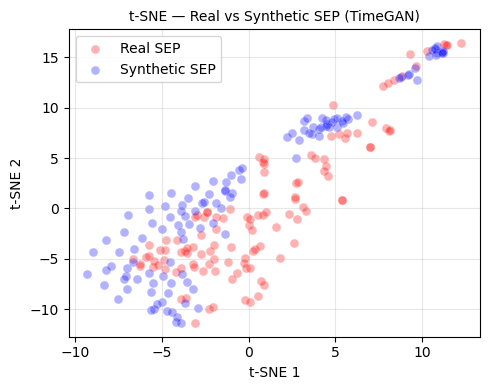

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pickle

# ── Load real vs synthetic from saved file ──
with open("./sep_samples/sep_real_vs_synthetic_timegan.pkl", "rb") as f:
    data = pickle.load(f)

X_real      = data["X_real_sep"]       # (118, t, c)
X_synthetic = data["X_synthetic_sep"]  # (118, t, c)

# ── Flatten for t-SNE ──
X_real_flat = X_real.reshape(len(X_real), -1)
X_syn_flat  = X_synthetic.reshape(len(X_synthetic), -1)

X_all    = np.concatenate([X_real_flat, X_syn_flat], axis=0)
y_labels = np.array([0] * len(X_real_flat) + [1] * len(X_syn_flat))

# ── t-SNE ──
print("Running t-SNE …")
tsne   = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_all)

# ── Plot ──
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(X_tsne[y_labels==0, 0], X_tsne[y_labels==0, 1],
           c="red",  label="Real SEP",      alpha=0.3, s=40, edgecolors="white", linewidths=0.3)
ax.scatter(X_tsne[y_labels==1, 0], X_tsne[y_labels==1, 1],
           c="blue", label="Synthetic SEP", alpha=0.3, s=40, edgecolors="white", linewidths=0.3)

ax.set_title("t-SNE — Real vs Synthetic SEP (TimeGAN)", fontsize=10)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()